使用5分K、日盤資料

In [166]:
import pandas as pd

df = pd.read_csv(f"TXF_1T_20240415.csv", index_col=0)
df.index = pd.to_datetime(df.index)

df = df.resample('1T', label='right', closed='right').agg(
    {'Open'  :'first',
     'High'  :'max',
     'Low'   :'min',
     'Close' :'last',
     'Volume':'sum',
     '大戶買進' :'sum',
     '散戶買進' :'sum',
     '大戶掛單' :'sum',
     '散戶掛單' :'sum'
    })

df = df.fillna(method='ffill')
#df= df.between_time('08:44:59', '13:45:01') #日盤
#df= df.between_time('14:59:59', '05:00:01') #夜盤
df = pd.concat([df.between_time('14:59:59', '05:00:01'), df.between_time('08:44:59', '13:45:01')]).sort_index() #日盤+夜盤
df

,Open,High,Low,Close,Volume,大戶買進,散戶買進,大戶掛單,散戶掛單
2020-03-22 08:46:00,9041.0,9050.0,9036.0,9037.0,889.0,0.0,3.0,0.0,75.045455
2020-03-22 08:47:00,9044.0,9049.0,9035.0,9042.0,422.0,35.0,6.0,0.0,226.470588
2020-03-22 08:48:00,9048.0,9050.0,9035.0,9049.0,85.0,42.0,11.0,0.0,550.666667
2020-03-22 08:49:00,9040.0,9050.0,9035.0,9035.0,473.0,63.0,11.0,0.0,836.555556
2020-03-22 08:50:00,9041.0,9059.0,9037.0,9044.0,301.0,77.0,11.0,0.0,1211.416667
...,...,...,...,...,...,...,...,...,...
2024-04-13 04:56:00,20500.0,20501.0,20499.0,20500.0,36.0,-210.0,-4316.0,10.0,8425.105263
2024-04-13 04:57:00,20499.0,20499.0,20497.0,20498.0,25.0,-210.0,-4315.0,0.0,8427.357143
2024-04-13 04:58:00,20496.0,20498.0,20492.0,20495.0,116.0,-210.0,-4352.0,0.0,8455.554054
2024-04-13 04:59:00,20494.0,20495.0,20489.0,20491.0,81.0,-210.0,-4353.0,-1.0,8484.132075


In [167]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from matplotlib.ticker import StrMethodFormatter
from backtesting.lib import _EQUITY_AGG

def figure(strategy):   

    equity_data = strategy._equity_curve.resample('1D', label='right').agg(_EQUITY_AGG).dropna(how='all')
    equity_data['DrawdownPct'] = equity_data['DrawdownPct'].multiply(-100)

    f, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(19.2, 10.8), gridspec_kw={'height_ratios': [5, 2]})

    ax1.grid(linestyle = '--', linewidth = 1)
    ax1.plot(equity_data['Equity'])
    ax1.set(ylabel="Equity($)")
    ax1.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
    date_form = DateFormatter("%Y-%m-%d")
    ax1.xaxis.set_major_formatter(date_form)
    ax1.xaxis.set_major_locator(mdates.DayLocator(interval=60))
    ax2.grid(linestyle = '--', linewidth = 1)
    ax2.plot(equity_data['DrawdownPct'], color="red")
    ax2.set(ylabel="DrawdownPct(%)")
    ax2.fill_between(equity_data['DrawdownPct'].index, equity_data['DrawdownPct'], where=(equity_data['DrawdownPct'] <= 0), color="red")   
    f.subplots_adjust(hspace=0)
    f.autofmt_xdate()
    plt.show()

多單策略-1

In [169]:
from backtesting import Strategy
from backtesting.lib import crossover
import talib as ta
from datetime import time
from backtesting import Backtest

class MyStrategy(Strategy):
    #MACD
    fast = 8
    slow = 57
    signal = 20
    def init(self):
        self.macd, self.signal, _ = self.I(ta.MACD, self.data.Close, fastperiod=self.fast, slowperiod=self.slow, signalperiod=self.signal)

    def next(self):
        current_time = self.data.index[-1].time()
        if ((current_time >= time(9, 15)) and (current_time <= time(13, 15))) or (((current_time >= time(15, 30)) and (current_time <= time(23, 59, 59))) or ((current_time >= time(0, 0)) and (current_time <= time(4, 30)))):
            if (not self.position.is_long):
                if (self.data.大戶買進[-1] > self.data.散戶買進[-1]) and (self.data.大戶買進[-2] < self.data.散戶買進[-2]):
                    self.buy(size=200)
            
            elif (self.position.is_long):    
                if (self.data.大戶買進[-1] < self.data.散戶買進[-1]) and (self.data.大戶買進[-2] > self.data.散戶買進[-2]):
                    self.position.close()
                
        if self.position and ((current_time >= time(13, 15) and current_time <= time(13, 45)) or (current_time >= time(4, 30) and current_time <= time(5, 00))):
            self.position.close()

Start                     2020-03-22 08:46:00
End                       2024-04-13 05:00:00
Duration                   1482 days 20:14:00
Exposure Time [%]                    4.870615
Equity Final [$]                    100278.65
Equity Peak [$]                     642024.55
Return [%]                          -79.94427
Buy & Hold Return [%]              126.756667
Return (Ann.) [%]                  -32.812843
Volatility (Ann.) [%]               25.623213
Sharpe Ratio                              0.0
Sortino Ratio                             0.0
Calmar Ratio                              0.0
Max. Drawdown [%]                  -85.128505
Avg. Drawdown [%]                   -1.703878
Max. Drawdown Duration     1443 days 16:30:00
Avg. Drawdown Duration       17 days 00:50:00
# Trades                                 1465
Win Rate [%]                        45.187713
Best Trade [%]                       1.717917
Worst Trade [%]                     -3.264982
Avg. Trade [%]                    

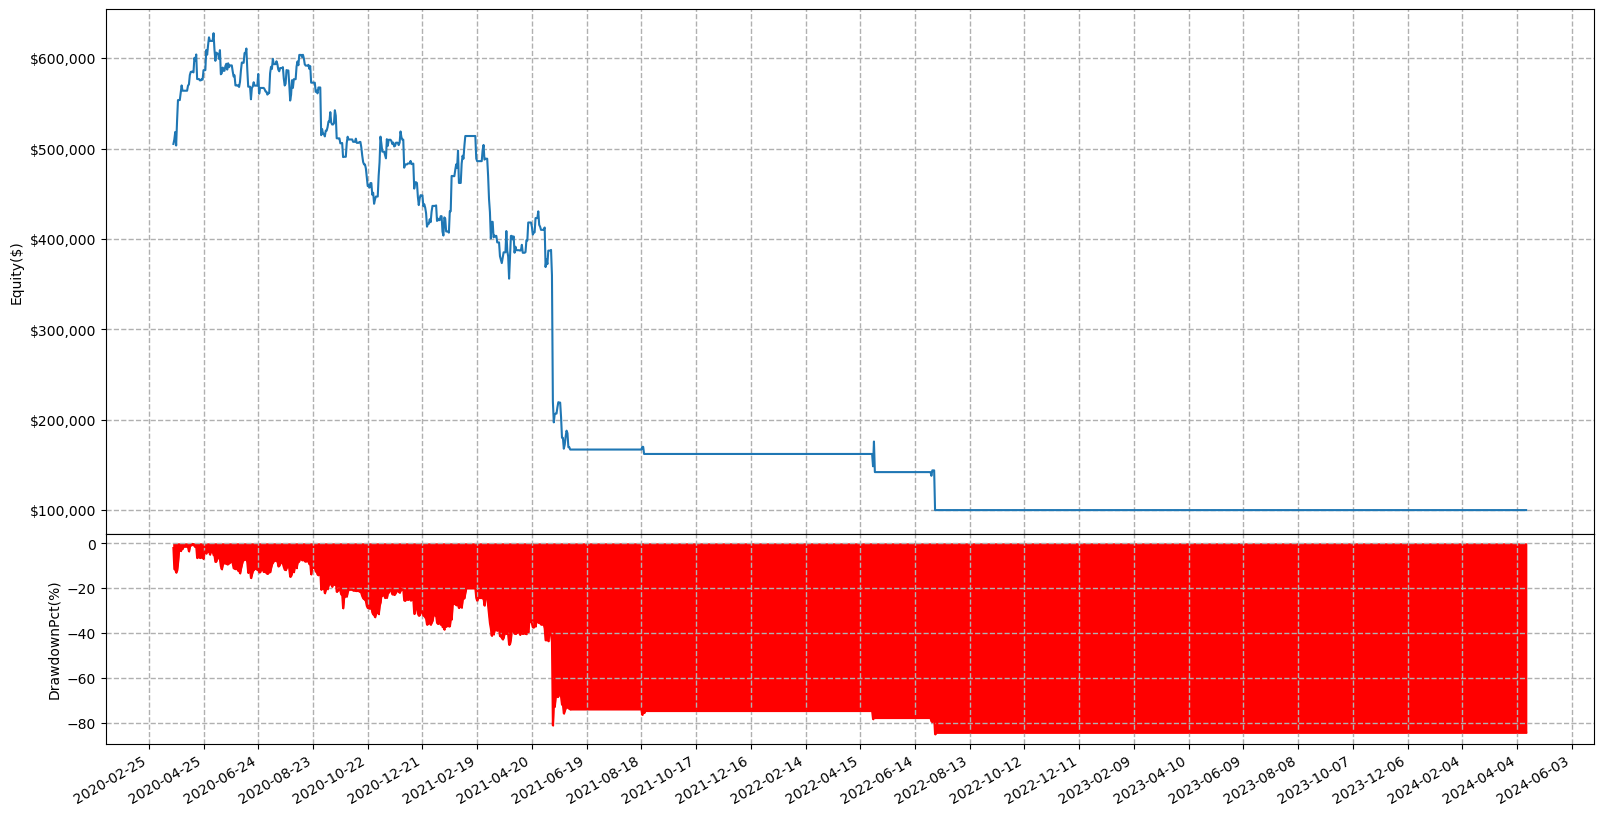

In [170]:
bt = Backtest(df, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
#Backtest(資料名稱, 策略名稱, cash=初始資金, commission=交易成本, hedging=是否優先對之前操作進行抵銷(競賽限定一次只能持有一口), exclusive_orders=每筆新交易是否關閉上一次的交易, margin=初始保證金比例)
stats = bt.run()
print(stats)
figure(stats)

多單策略-2(加入MACD、大戶散戶掛單)

In [171]:
class MyStrategy(Strategy):
    #MACD
    fast = 5
    slow = 40
    signal = 20
    def init(self):
        self.macd, self.signal, _ = self.I(ta.MACD, self.data.Close, fastperiod=self.fast, slowperiod=self.slow, signalperiod=self.signal)

    def next(self):
        current_time = self.data.index[-1].time()
        if ((current_time >= time(9, 15)) and (current_time <= time(13, 15))) or (((current_time >= time(15, 30)) and (current_time <= time(23, 59, 59))) or ((current_time >= time(0, 0)) and (current_time <= time(4, 30)))):
            if (not self.position.is_long):
                if crossover(self.macd, self.signal):
                    if (self.data.大戶掛單[-1] > self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] < self.data.散戶掛單[-2]):
                        self.buy(size=200)
                    elif (self.data.大戶買進[-1] > self.data.散戶買進[-1]) and (self.data.大戶買進[-2] < self.data.散戶買進[-2]):
                        self.buy(size=200)
            
            elif (self.position.is_long):    
                if crossover(self.signal, self.macd):
                    if (self.data.大戶掛單[-1] < self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] > self.data.散戶掛單[-2]):
                        self.position.close()
                    elif (self.data.大戶買進[-1] < self.data.散戶買進[-1]) and (self.data.大戶買進[-2] > self.data.散戶買進[-2]):
                        self.position.close()
                    
                        
        if self.position and ((current_time >= time(13, 15) and current_time <= time(13, 45)) or (current_time >= time(4, 30) and current_time <= time(5, 00))):
            self.position.close()

Start                     2020-03-22 08:46:00
End                       2024-04-13 05:00:00
Duration                   1482 days 20:14:00
Exposure Time [%]                    3.569292
Equity Final [$]                    753316.95
Equity Peak [$]                      774769.3
Return [%]                           50.66339
Buy & Hold Return [%]              126.756667
Return (Ann.) [%]                   10.606901
Volatility (Ann.) [%]               17.936371
Sharpe Ratio                         0.591363
Sortino Ratio                        1.016998
Calmar Ratio                         0.459175
Max. Drawdown [%]                  -23.099924
Avg. Drawdown [%]                   -0.942379
Max. Drawdown Duration      417 days 20:35:00
Avg. Drawdown Duration        7 days 18:02:00
# Trades                                  185
Win Rate [%]                        51.891892
Best Trade [%]                       1.713045
Worst Trade [%]                     -1.735312
Avg. Trade [%]                    

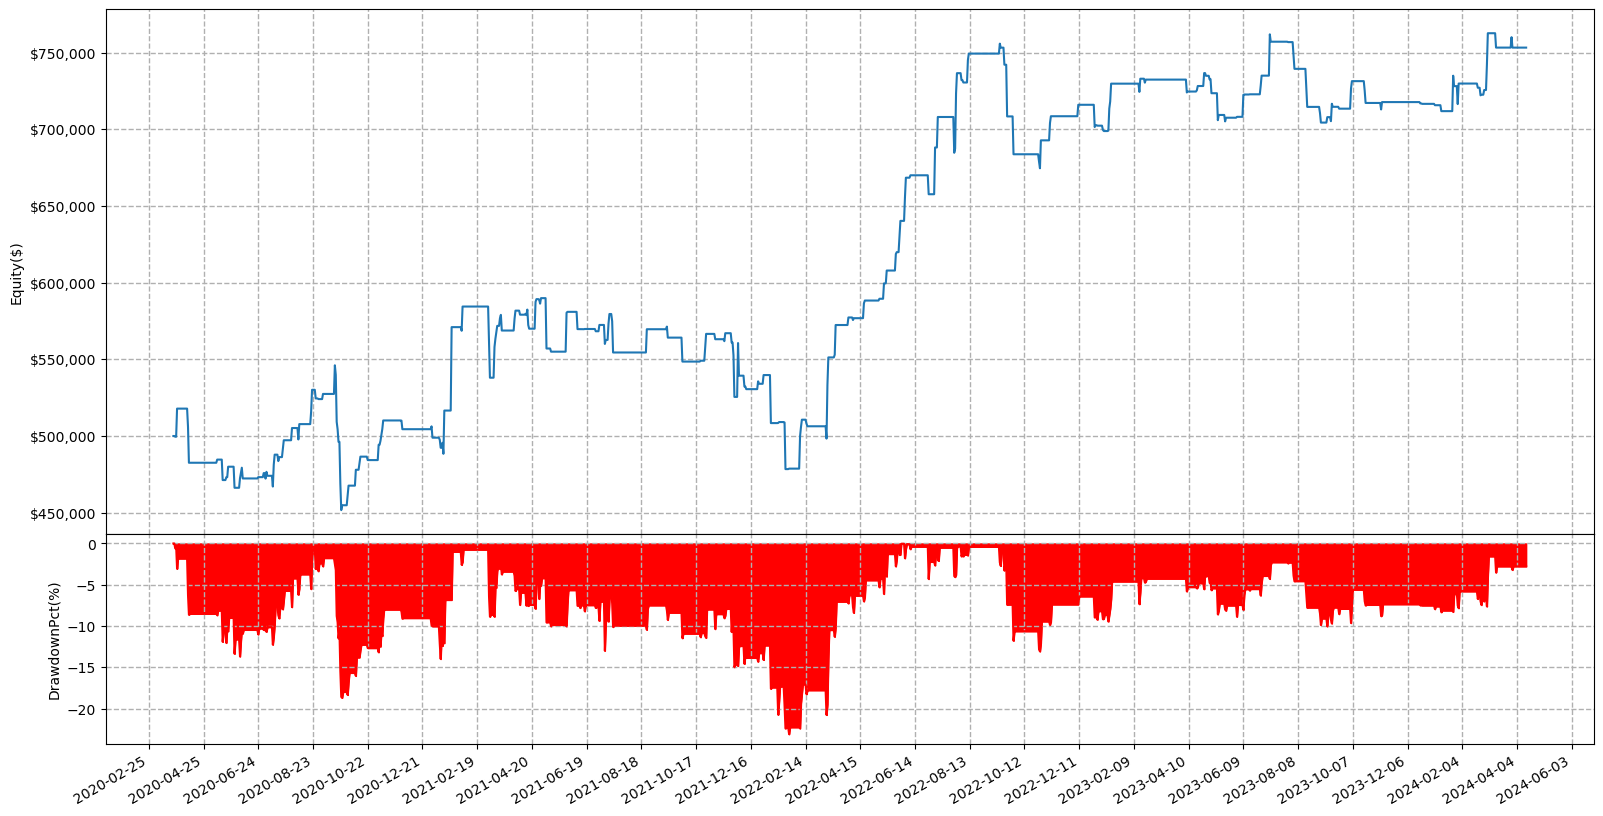

In [172]:
bt = Backtest(df, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
#Backtest(資料名稱, 策略名稱, cash=初始資金, commission=交易成本, hedging=是否優先對之前操作進行抵銷(競賽限定一次只能持有一口), exclusive_orders=每筆新交易是否關閉上一次的交易, margin=初始保證金比例)
stats = bt.run()
print(stats)
figure(stats)

多單策略-3(加入停損)

In [173]:
class MyStrategy(Strategy):
    #MACD
    fast = 5
    slow = 40
    signal = 20
    #止損
    stop_pct = 5   #表示0.5%
    def init(self):
        self.macd, self.signal, _ = self.I(ta.MACD, self.data.Close, fastperiod=self.fast, slowperiod=self.slow, signalperiod=self.signal)

    def next(self):
        current_time = self.data.index[-1].time()
        if ((current_time >= time(9, 15)) and (current_time <= time(13, 15))) or (((current_time >= time(15, 30)) and (current_time <= time(23, 59, 59))) or ((current_time >= time(0, 0)) and (current_time <= time(4, 30)))):
            if (not self.position.is_long):
                if crossover(self.macd, self.signal):
                    if (self.data.大戶掛單[-1] > self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] < self.data.散戶掛單[-2]):
                        self.buy(size=200)
                    elif (self.data.大戶買進[-1] > self.data.散戶買進[-1]) and (self.data.大戶買進[-2] < self.data.散戶買進[-2]):
                        self.buy(size=200)
                    
            
            elif (self.position.is_long):    
                if crossover(self.signal, self.macd):
                    if (self.data.大戶掛單[-1] < self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] > self.data.散戶掛單[-2]):
                        self.position.close()
                    elif (self.data.大戶買進[-1] < self.data.散戶買進[-1]) and (self.data.大戶買進[-2] > self.data.散戶買進[-2]):
                        self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
                        
        if self.position and ((current_time >= time(13, 15) and current_time <= time(13, 45)) or (current_time >= time(4, 30) and current_time <= time(5, 00))):
            self.position.close()

Start                     2020-03-22 08:46:00
End                       2024-04-13 05:00:00
Duration                   1482 days 20:14:00
Exposure Time [%]                    3.226174
Equity Final [$]                    845716.95
Equity Peak [$]                      859701.7
Return [%]                           69.14339
Buy & Hold Return [%]              126.756667
Return (Ann.) [%]                   13.799641
Volatility (Ann.) [%]               15.028539
Sharpe Ratio                         0.918229
Sortino Ratio                        1.886044
Calmar Ratio                         0.930435
Max. Drawdown [%]                   -14.83139
Avg. Drawdown [%]                   -0.678781
Max. Drawdown Duration      371 days 00:03:00
Avg. Drawdown Duration        5 days 08:44:00
# Trades                                  185
Win Rate [%]                        50.810811
Best Trade [%]                       1.713045
Worst Trade [%]                     -0.628088
Avg. Trade [%]                    

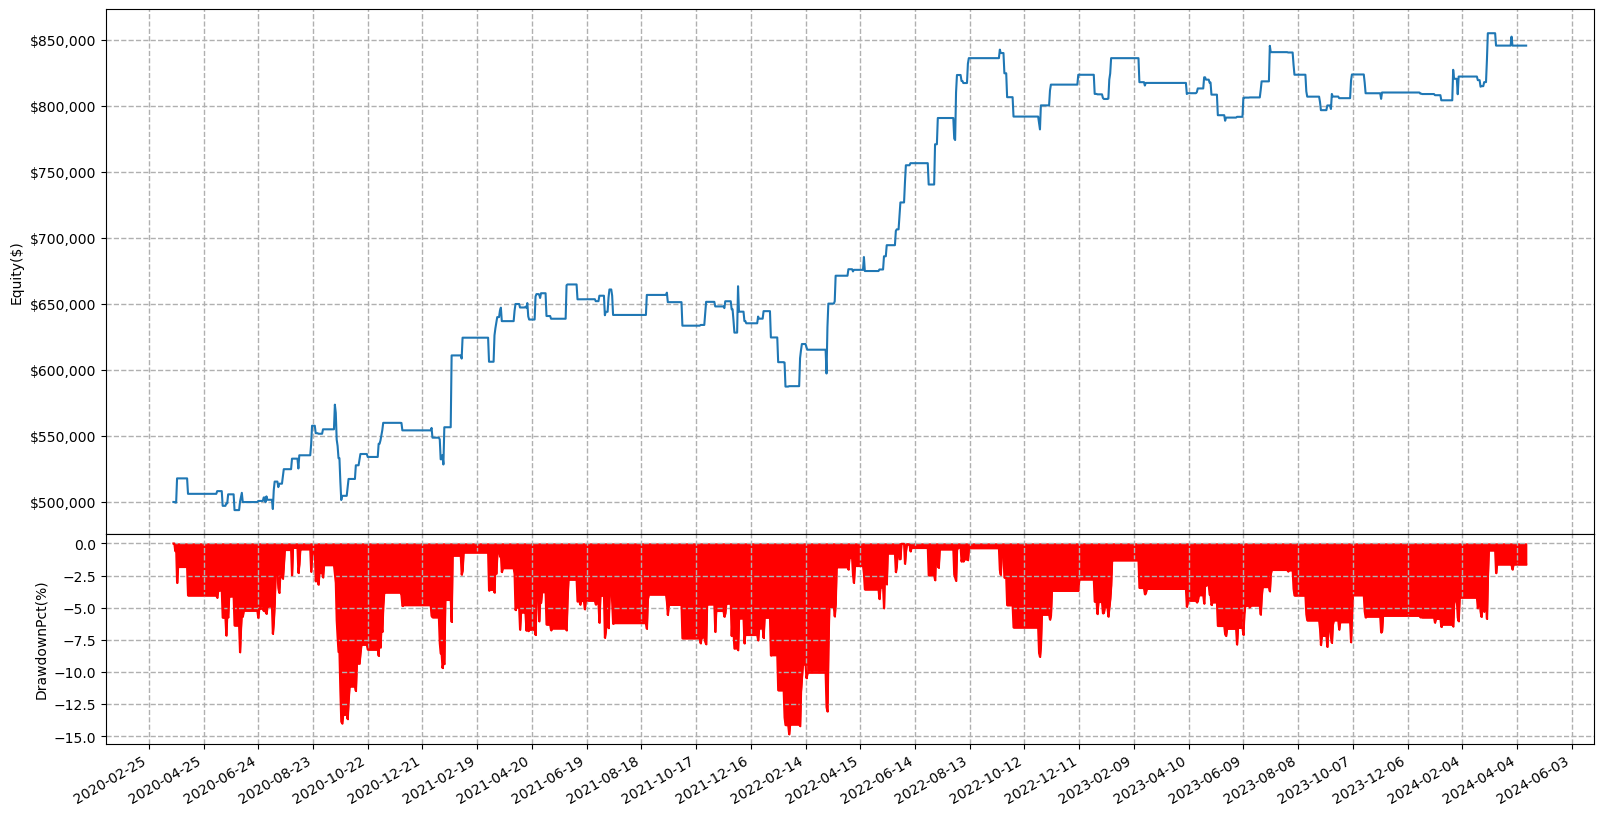

In [174]:
bt = Backtest(df, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
#Backtest(資料名稱, 策略名稱, cash=初始資金, commission=交易成本, hedging=是否優先對之前操作進行抵銷(競賽限定一次只能持有一口), exclusive_orders=每筆新交易是否關閉上一次的交易, margin=初始保證金比例)
stats = bt.run()
print(stats)
figure(stats)

空單策略-1

In [175]:
class MyStrategy(Strategy):
    #MACD
    fast = 5
    slow = 40
    signal = 20
    #止損
    stop_pct = 5   #表示0.5%
    wait_num = 10
    current_num = 0
    def init(self):
        self.macd, self.signal, _ = self.I(ta.MACD, self.data.Close, fastperiod=self.fast, slowperiod=self.slow, signalperiod=self.signal)

    def next(self):
        current_time = self.data.index[-1].time()
        if ((current_time >= time(9, 15)) and (current_time <= time(13, 15))) or (((current_time >= time(15, 30)) and (current_time <= time(23, 59, 59))) or ((current_time >= time(0, 0)) and (current_time <= time(4, 30)))):
            #沒有持有多單或空單就進入判斷是否要做多做空
            if (not self.position.is_long) and (not self.position.is_short):
                if crossover(self.macd, self.signal):
                    if (self.data.大戶掛單[-1] > self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] < self.data.散戶掛單[-2]):
                        self.buy(size=200)
                    elif (self.data.大戶買進[-1] > self.data.散戶買進[-1]) and (self.data.大戶買進[-2] < self.data.散戶買進[-2]):
                        self.buy(size=200)
                elif crossover(self.signal, self.macd):
                    if (self.data.大戶買進[-1] < self.data.散戶買進[-1]) and (self.data.大戶買進[-2] > self.data.散戶買進[-2]):
                        if(self.current_num > self.wait_num):
                            self.sell(size=200)
                            self.current_num = 0
                        self.current_num += 1

            elif (self.position.is_long):    
                if crossover(self.signal, self.macd):
                    if (self.data.大戶掛單[-1] < self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] > self.data.散戶掛單[-2]):
                        self.position.close()
                    elif (self.data.大戶買進[-1] < self.data.散戶買進[-1]) and (self.data.大戶買進[-2] > self.data.散戶買進[-2]):
                        self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
            
            elif (self.position.is_short):    
                if crossover(self.macd, self.signal):
                    if (self.data.大戶買進[-1] > self.data.散戶買進[-1]) and (self.data.大戶買進[-2] < self.data.散戶買進[-2]):
                        self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
                        
        if self.position and ((current_time >= time(13, 15) and current_time <= time(13, 45)) or (current_time >= time(4, 30) and current_time <= time(5, 00))):
            self.position.close()

Start                     2020-03-22 08:46:00
End                       2024-04-13 05:00:00
Duration                   1482 days 20:14:00
Exposure Time [%]                    3.316456
Equity Final [$]                    833824.75
Equity Peak [$]                      847809.5
Return [%]                           66.76495
Buy & Hold Return [%]              126.756667
Return (Ann.) [%]                   13.403954
Volatility (Ann.) [%]               15.204755
Sharpe Ratio                         0.881563
Sortino Ratio                        1.790681
Calmar Ratio                         0.822887
Max. Drawdown [%]                  -16.288936
Avg. Drawdown [%]                   -0.705477
Max. Drawdown Duration      421 days 18:54:00
Avg. Drawdown Duration        5 days 17:43:00
# Trades                                  192
Win Rate [%]                             50.0
Best Trade [%]                       1.713045
Worst Trade [%]                     -0.628088
Avg. Trade [%]                    

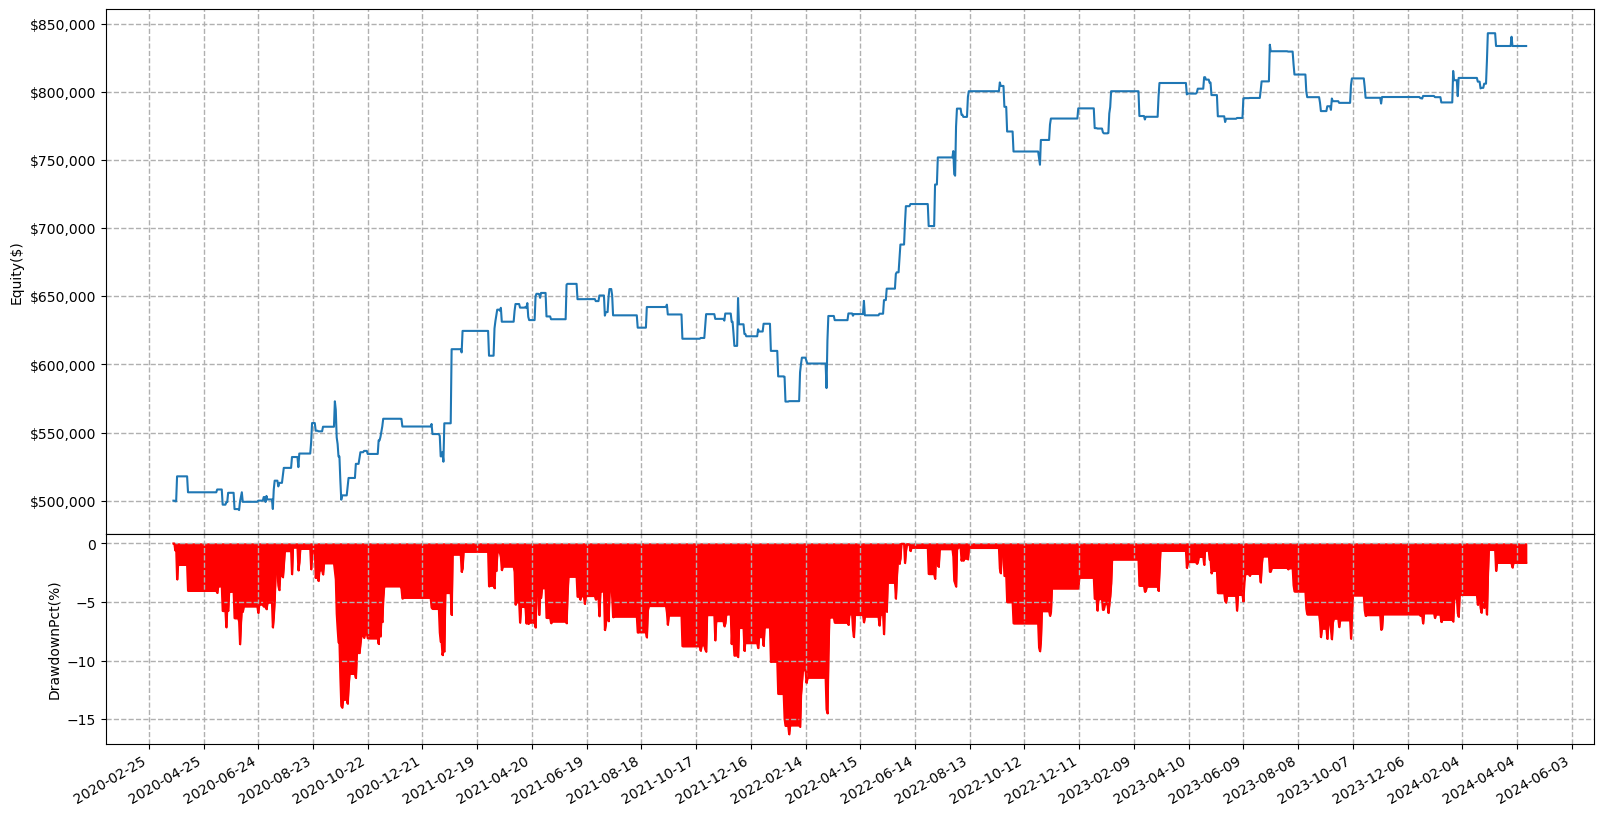

In [176]:
bt = Backtest(df, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
stats = bt.run()
print(stats)
figure(stats)

空單策略-2

In [177]:
class MyStrategy(Strategy):
    #MACD
    fast = 5
    slow = 40
    signal = 20
    #止損
    stop_pct = 5   #表示0.5%
    wait_num = 10
    current_num = 0
    def init(self):
        self.macd, self.signal, _ = self.I(ta.MACD, self.data.Close, fastperiod=self.fast, slowperiod=self.slow, signalperiod=self.signal)

    def next(self):
        current_time = self.data.index[-1].time()
        if ((current_time >= time(9, 15)) and (current_time <= time(13, 15))) or (((current_time >= time(15, 30)) and (current_time <= time(23, 59, 59))) or ((current_time >= time(0, 0)) and (current_time <= time(4, 30)))):
            #沒有持有多單或空單就進入判斷是否要做多做空
            if (not self.position.is_long) and (not self.position.is_short):
                if crossover(self.macd, self.signal):
                    if (self.data.大戶掛單[-1] > self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] < self.data.散戶掛單[-2]):
                        self.buy(size=200)
                    elif (self.data.大戶買進[-1] > self.data.散戶買進[-1]) and (self.data.大戶買進[-2] < self.data.散戶買進[-2]):
                        self.buy(size=200)
                elif crossover(self.signal, self.macd):
                    if (self.data.大戶掛單[-1] < self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] > self.data.散戶掛單[-2]):
                        self.sell(size=200)

            elif (self.position.is_long):    
                if crossover(self.signal, self.macd):
                    if (self.data.大戶掛單[-1] < self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] > self.data.散戶掛單[-2]):
                        self.position.close()
                    elif (self.data.大戶買進[-1] < self.data.散戶買進[-1]) and (self.data.大戶買進[-2] > self.data.散戶買進[-2]):
                        self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
            
            elif (self.position.is_short):    
                if crossover(self.macd, self.signal):
                    if (self.data.大戶掛單[-1] > self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] < self.data.散戶掛單[-2]):
                        self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
                        
        if self.position and ((current_time >= time(13, 15) and current_time <= time(13, 45)) or (current_time >= time(4, 30) and current_time <= time(5, 00))):
            self.position.close()

Start                     2020-03-22 08:46:00
End                       2024-04-13 05:00:00
Duration                   1482 days 20:14:00
Exposure Time [%]                    4.035995
Equity Final [$]                    786127.35
Equity Peak [$]                      896275.3
Return [%]                           57.22547
Buy & Hold Return [%]              126.756667
Return (Ann.) [%]                   11.772807
Volatility (Ann.) [%]               16.964963
Sharpe Ratio                         0.693948
Sortino Ratio                        1.315201
Calmar Ratio                           0.6177
Max. Drawdown [%]                  -19.059089
Avg. Drawdown [%]                   -0.763668
Max. Drawdown Duration      370 days 23:05:00
Avg. Drawdown Duration        5 days 13:49:00
# Trades                                  224
Win Rate [%]                        48.660714
Best Trade [%]                       1.713045
Worst Trade [%]                     -0.628088
Avg. Trade [%]                    

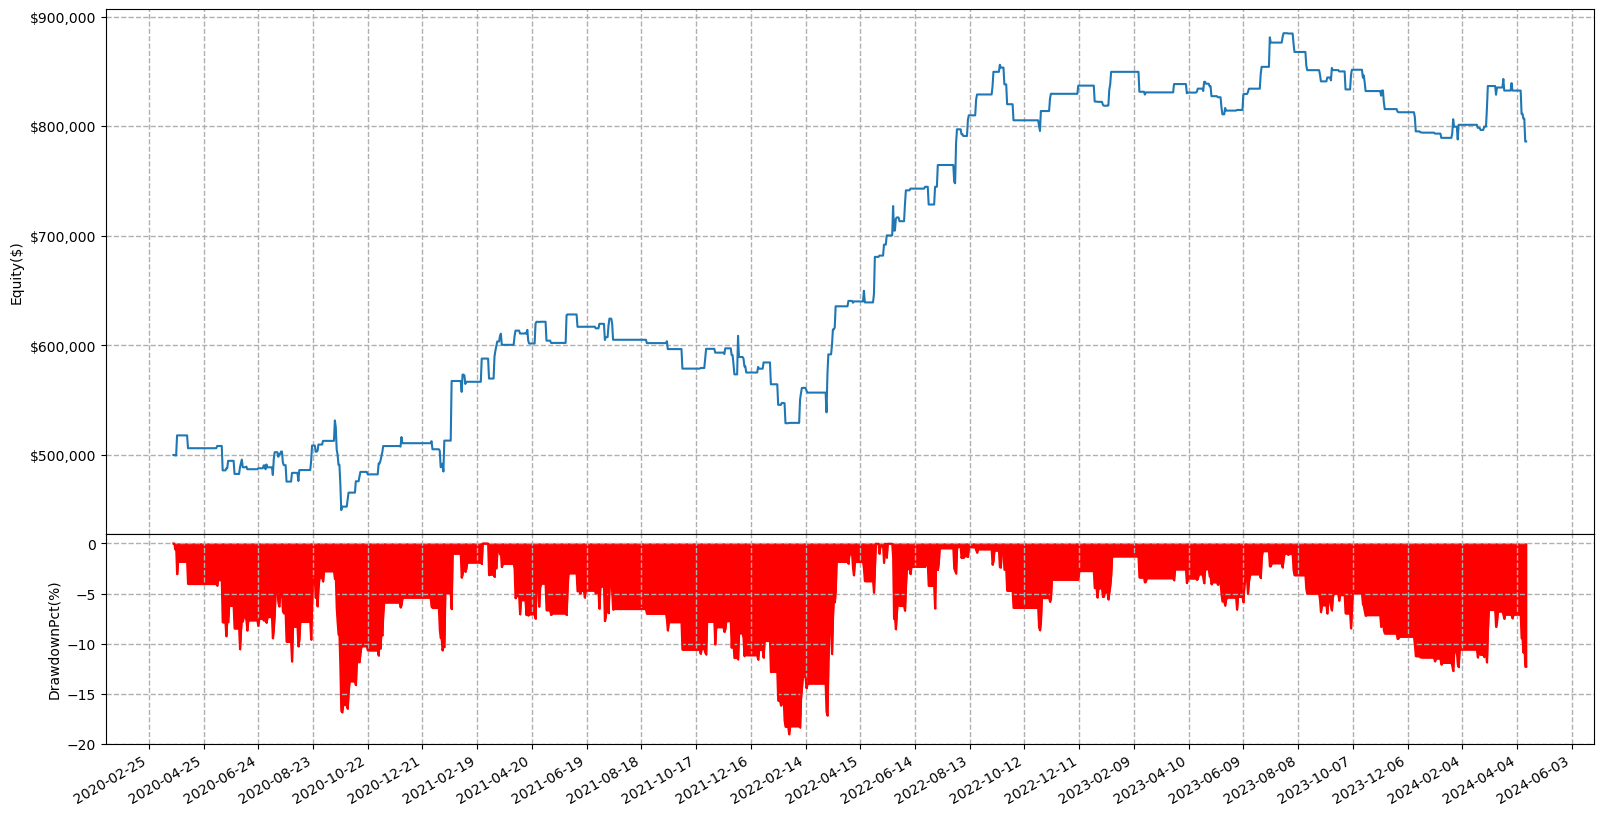

In [178]:
bt = Backtest(df, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
stats = bt.run()
print(stats)
figure(stats)

最佳化參數

In [179]:
class MyStrategy(Strategy):
    #MACD
    fast = 5
    slow = 40
    signal = 20
    #止損
    stop_pct = 5   #表示0.5%
    wait_num = 10
    current_num = 0
    def init(self):
        self.macd, self.signal, _ = self.I(ta.MACD, self.data.Close, fastperiod=self.fast, slowperiod=self.slow, signalperiod=self.signal)

    def next(self):
        current_time = self.data.index[-1].time()
        if ((current_time >= time(9, 15)) and (current_time <= time(13, 15))) or (((current_time >= time(15, 30)) and (current_time <= time(23, 59, 59))) or ((current_time >= time(0, 0)) and (current_time <= time(4, 30)))):
            #沒有持有多單或空單就進入判斷是否要做多做空
            if (not self.position.is_long) and (not self.position.is_short):
                if crossover(self.macd, self.signal):
                    if (self.data.大戶掛單[-1] > self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] < self.data.散戶掛單[-2]):
                        self.buy(size=200)
                    elif (self.data.大戶買進[-1] > self.data.散戶買進[-1]) and (self.data.大戶買進[-2] < self.data.散戶買進[-2]):
                        self.buy(size=200)
                elif crossover(self.signal, self.macd):
                    if (self.data.大戶買進[-1] < self.data.散戶買進[-1]) and (self.data.大戶買進[-2] > self.data.散戶買進[-2]):
                        if(self.current_num > self.wait_num):
                            self.sell(size=200)
                            self.current_num = 0
                        self.current_num += 1

            elif (self.position.is_long):    
                if crossover(self.signal, self.macd):
                    if (self.data.大戶掛單[-1] < self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] > self.data.散戶掛單[-2]):
                        self.position.close()
                    elif (self.data.大戶買進[-1] < self.data.散戶買進[-1]) and (self.data.大戶買進[-2] > self.data.散戶買進[-2]):
                        self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
            
            elif (self.position.is_short):    
                if crossover(self.macd, self.signal):
                    if (self.data.大戶買進[-1] > self.data.散戶買進[-1]) and (self.data.大戶買進[-2] < self.data.散戶買進[-2]):
                        self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
                        
        if self.position and ((current_time >= time(13, 15) and current_time <= time(13, 45)) or (current_time >= time(4, 30) and current_time <= time(5, 00))):
            self.position.close()

  0%|          | 0/18 [00:00<?, ?it/s]

Start                     2020-03-22 08:46:00
End                       2022-12-31 23:59:00
Duration                   1014 days 15:13:00
Exposure Time [%]                    3.706676
Equity Final [$]                     819687.8
Equity Peak [$]                     845420.05
Return [%]                           63.93756
Buy & Hold Return [%]               55.980967
Return (Ann.) [%]                   19.453711
Volatility (Ann.) [%]               19.568579
Sharpe Ratio                          0.99413
Sortino Ratio                        2.053701
Calmar Ratio                         0.998851
Max. Drawdown [%]                  -19.476093
Avg. Drawdown [%]                   -0.654974
Max. Drawdown Duration      407 days 06:56:00
Avg. Drawdown Duration        3 days 17:59:00
# Trades                                  148
Win Rate [%]                        53.378378
Best Trade [%]                       1.713045
Worst Trade [%]                     -0.708257
Avg. Trade [%]                    

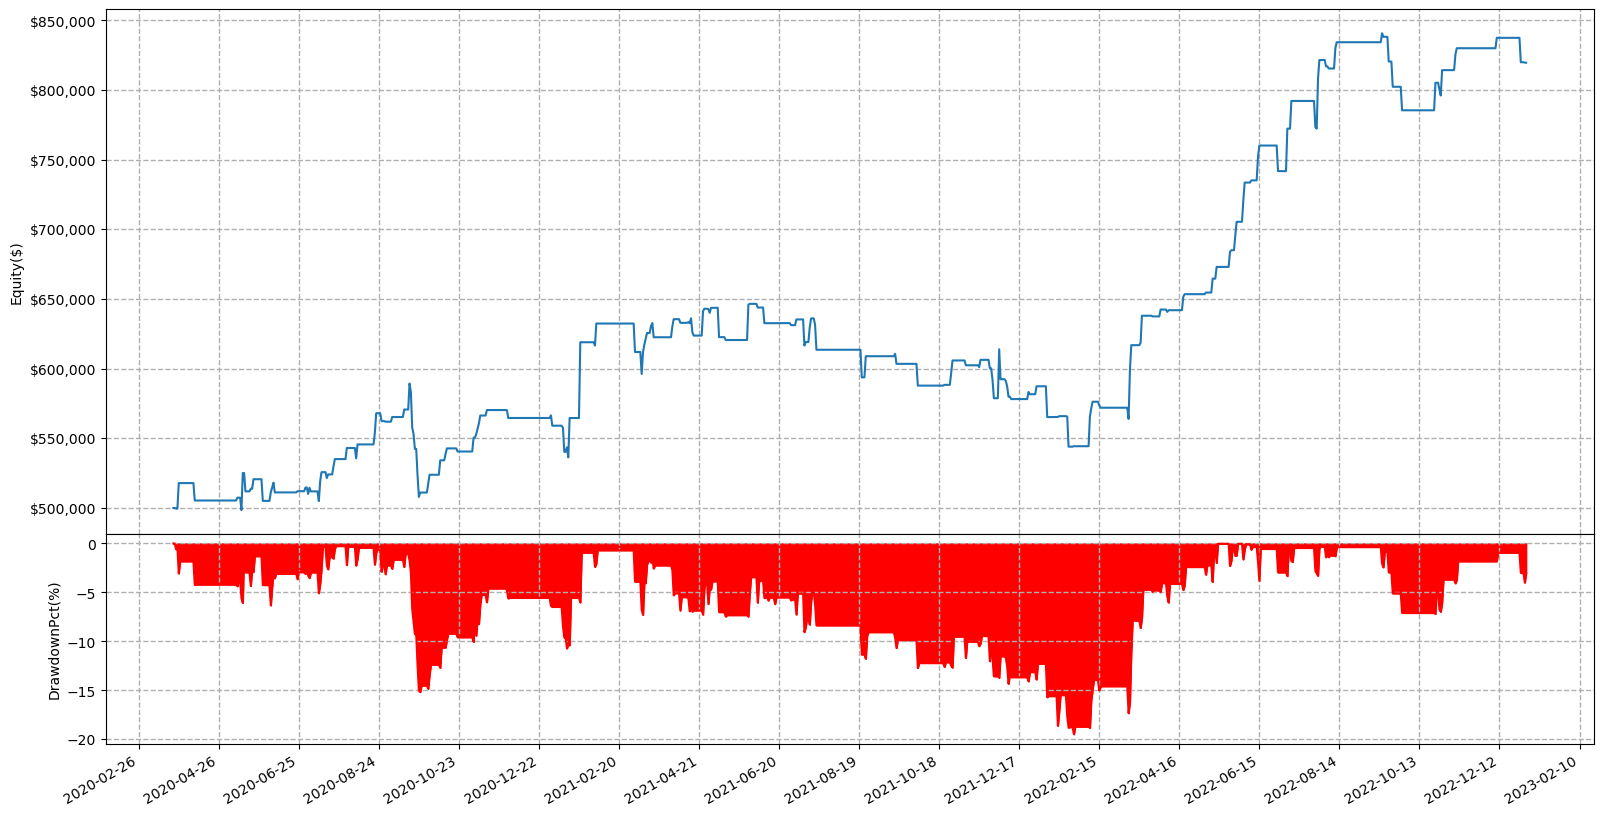

In [180]:
df_inner=df[df.index.year<2023] #樣本內2020-2022
bt_op = Backtest(df_inner, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
stats_op = bt_op.optimize(wait_num=range(5,11,1), stop_pct=range(5,11,1))
print(stats_op)
print(stats_op['_strategy'])
figure(stats_op)

將最佳化的結果代入策略中，回測樣本內外的數據

In [1]:
class MyStrategy(Strategy):
    #MACD
    fast = 5
    slow = 40
    signal = 20
    #止損
    stop_pct = 6   #表示0.6%
    wait_num = 5
    current_num = 0
    def init(self):
        self.macd, self.signal, _ = self.I(ta.MACD, self.data.Close, fastperiod=self.fast, slowperiod=self.slow, signalperiod=self.signal)

    def next(self):
        current_time = self.data.index[-1].time()
        if ((current_time >= time(9, 30)) and (current_time <= time(12, 30))) or (((current_time >= time(15, 30)) and (current_time <= time(23, 59, 59))) or ((current_time >= time(0, 0)) and (current_time <= time(4, 30)))):
            #沒有持有多單或空單就進入判斷是否要做多做空
            if (not self.position.is_long) and (not self.position.is_short):
                if crossover(self.macd, self.signal):
                    if (self.data.大戶掛單[-1] > self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] < self.data.散戶掛單[-2]):
                        self.buy(size=200)
                    elif (self.data.大戶買進[-1] > self.data.散戶買進[-1]) and (self.data.大戶買進[-2] < self.data.散戶買進[-2]):
                        self.buy(size=200)
                elif crossover(self.signal, self.macd):
                    if (self.data.大戶買進[-1] < self.data.散戶買進[-1]) and (self.data.大戶買進[-2] > self.data.散戶買進[-2]):
                        if(self.current_num > self.wait_num):
                            self.sell(size=200)
                            self.current_num = 0
                        self.current_num += 1

            elif (self.position.is_long):    
                if crossover(self.signal, self.macd):
                    if (self.data.大戶掛單[-1] < self.data.散戶掛單[-1]) and (self.data.大戶掛單[-2] > self.data.散戶掛單[-2]):
                        self.position.close()
                    elif (self.data.大戶買進[-1] < self.data.散戶買進[-1]) and (self.data.大戶買進[-2] > self.data.散戶買進[-2]):
                        self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
            
            elif (self.position.is_short):    
                if crossover(self.macd, self.signal):
                    if (self.data.大戶買進[-1] > self.data.散戶買進[-1]) and (self.data.大戶買進[-2] < self.data.散戶買進[-2]):
                        self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
                        
        if self.position and ((current_time >= time(12, 30) and current_time <= time(13, 45)) or (current_time >= time(4, 30) and current_time <= time(5, 00))):
            self.position.close()
            
bt = Backtest(df, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
stats = bt.run()
print(stats)
figure(stats)

NameError: name 'Strategy' is not defined